# sDPO LCBv6: Qwen3-8B baseline / NGU summary

Pulls the `sdpo_lcbv6_qwen3_8b_*` **training** runs from W&B project
`ai2-llm/open_instruct_internal` and reproduces the same analysis as
`deepcoder_plots.ipynb` (raw pass@1 table + `improvement over the initial model, by
difficulty bucket` table), plus the training-curve / difficulty-bar plots from
`deepscaler_ngu_plots.ipynb` -- which are possible here because, unlike the DeepCoder
runs, these log their eval history point-by-point inside a single wandb run.

**Settings covered** (1 seed each, `Qwen/Qwen3-8B`, `mnoukhov/sdpo_lcbv6`, `beta=0`,
`lr=1e-6`, `total_episodes=20480` = 320 steps at 64 completions/step, `local_eval_every=32`):

| Group | Setting | N (`num_unique_prompts_rollout`) | K (`num_samples_per_prompt_rollout`) | `never_give_up` |
| --- | --- | --- | --- | --- |
| GRPO Baseline | `N=8, K=8`   | 8 | 8  | 0 |
| GRPO Baseline | `N=4, K=16`  | 4 | 16 | 0 |
| GRPO Baseline | `N=2, K=32`  | 2 | 32 | 0 |
| NGU | `NGU p=0.5`   | 8 | 8 | 0.5   |
| NGU | `NGU p=0.75`  | 8 | 8 | 0.75  |
| NGU | `NGU p=0.875` | 8 | 8 | 0.875 |

The NGU settings share the `N=8, K=8` baseline's rollout shape, so that row is the
apples-to-apples comparison for them; `N=4, K=16` / `N=2, K=32` are the constant-budget
(`N*K = 64`) baseline sweep.

**Eval set.** `mnoukhov/sdpo_lcbv6`'s `test` split is 131 LiveCodeBench-v6 prompts:
`dataset_index` 0-81 are `code_stdio_lcbv6` (82 prompts) and 82-130 are
`code_functional_lcbv6` (49) -- one dataset repo whose rows carry two reward-fn labels, so
the runs log both a pooled `eval/pass_at_1` and per-label
`eval/pass_at_1/code_{stdio,functional}_lcbv6`. The index split is asserted against those
logged per-label metrics below rather than assumed. Eval decoding is
`eval_temperature=0.7`, `eval_top_p=0.95`, `eval_pass_at_k=4`.

**Best step.** Each run's own peak `eval/pass_at_1` over its logged eval history, computed
here rather than hardcoded (the DeepScaler notebooks' `best_step` convention, but
auto-selected, since these runs are single-seed and some are still in progress). The
registry cell prints the chosen step and how far each run's history reaches.

**Two difficulty schemes**, both plotted and tabulated:

1. **Measured** (`Model-measured`) -- the convention used by `deepcoder_plots.ipynb` /
   `deepscaler_ngu_plots.ipynb`: buckets derived from the dedicated initial-model difficulty
   run [`e8jly0yk`](https://wandb.ai/ai2-llm/open_instruct_internal/runs/e8jly0yk)
   (`Qwen/Qwen3-8B` zero-shot, `eval_only=True`, `eval_pass_at_k=32`, same
   `t=0.7 / top_p=0.95` decoding as the training runs' own evals, so it is a matched baseline
   rather than a differently-decoded one). This replaces an earlier attempt using
   [`gdaq4r7g`](https://wandb.ai/ai2-llm/open_instruct_internal/runs/gdaq4r7g), the same eval
   at `eval_pass_at_k=4`: 4 samples give only 5 distinct solve rates (0, .25, .5, .75, 1), so
   most of the eval set tied and the easy/medium boundary was decided by tie-breaking rather
   than by measured difficulty. `e8jly0yk`'s 32-sample solve rates are a genuine continuous
   signal, on par with the 32/128-sample difficulty runs behind the DeepCoder and DeepScaler
   notebooks.
2. **Official** (`LCB label`) -- LiveCodeBench's own `easy`/`medium`/`hard` label per problem,
   independent of any model. `mnoukhov/sdpo_lcbv6` doesn't carry it, so it is recovered from
   `SolverJ/lcbv6` and aligned to our rows by problem text (see that section).

Everything downstream is parameterized over a difficulty *scheme*, so each bucket plot/table
is produced twice, once per scheme.

In [1]:
from __future__ import annotations

import json
import re
import tempfile
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import wandb
from huggingface_hub import hf_hub_download
from IPython.display import display

try:
    import seaborn as sns
except ImportError as exc:
    raise ImportError("This notebook requires seaborn. Install it in the active environment before running.") from exc

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

In [2]:
PROJECT_PATH = "ai2-llm/open_instruct_internal"

EVAL_KEY = "eval/pass_at_1"  # pooled over both reward-fn subsets (all 131 prompts)
SUBSETS = {"stdio": "code_stdio_lcbv6", "functional": "code_functional_lcbv6"}
SUBSET_EVAL_KEYS = {label: f"eval/pass_at_1/{name}" for label, name in SUBSETS.items()}
EVAL_DATASET_REPO = "mnoukhov/sdpo_lcbv6"
EVAL_DATASET_FILE = "data/test-00000-of-00001.parquet"  # test split only; the train split is large and unused here
EVAL_PASS_AT_K = 4
K_VALUES = [1, 2, 4]
PASS_AT_K_HISTORY_COLS = {k: f"eval/pass_at_{k}_unbiased" for k in K_VALUES}

MAX_STEP = 320  # total_episodes=20480 / 64 completions per step
DIFFICULTY_RUN_ID = "e8jly0yk"  # zero-shot Qwen3-8B eval, t=0.7 / top_p=0.95, eval_pass_at_k=32
DIFFICULTY_PASS_AT_K = 32  # samples per prompt behind the solve rates the buckets are cut from
DIFFICULTY_RUN_K_VALUES = [1, 2, 4, 8, 16, 32]
INITIAL_RUN_NAME = "initial_eval"
DIFFICULTY_ORDER = ["hard", "medium", "easy"]

NOTEBOOK_DIR = Path.cwd() if Path.cwd().name == "notebooks" else Path.cwd() / "notebooks"
OUTPUT_DIR = NOTEBOOK_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
WANDB_CACHE_DIR = NOTEBOOK_DIR / ".wandb_cache"
WANDB_CACHE_DIR.mkdir(parents=True, exist_ok=True)

api = wandb.Api(timeout=90)

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/mnoukhov/.netrc.


## Run registry

One wandb run per setting (single seed), recorded by run id. `never_give_up` (the NGU `p`)
and `N`/`K` are read back out of each run's own wandb config and asserted against the label
here, so a mislabelled entry fails loudly instead of silently plotting the wrong run.

In [3]:
RUN_SPECS = [
    {"setting": "N=8, K=8", "run_id": "ch2j416p", "n": 8, "k": 8, "p": 0},
    {"setting": "N=4, K=16", "run_id": "66ts5801", "n": 4, "k": 16, "p": 0},
    {"setting": "N=2, K=32", "run_id": "zdhrg9vd", "n": 2, "k": 32, "p": 0},
    {"setting": "NGU p=0.5", "run_id": "r90bjb2l", "n": 8, "k": 8, "p": 0.5},
    {"setting": "NGU p=0.75", "run_id": "frp9g7u9", "n": 8, "k": 8, "p": 0.75},
    {"setting": "NGU p=0.875", "run_id": "i0cxsgsu", "n": 8, "k": 8, "p": 0.875},
]

BASELINE_SETTING_ORDER = ["N=8, K=8", "N=4, K=16", "N=2, K=32"]
NGU_ONLY_SETTING_ORDER = ["NGU p=0.5", "NGU p=0.75", "NGU p=0.875"]
NGU_SETTING_ORDER = ["N=8, K=8", *NGU_ONLY_SETTING_ORDER]  # NGU sweep against its matched N=8,K=8 baseline
ALL_SETTING_ORDER = [*BASELINE_SETTING_ORDER, *NGU_ONLY_SETTING_ORDER]

for spec in RUN_SPECS:
    config = api.run(f"{PROJECT_PATH}/{spec['run_id']}").config
    actual = (config["num_unique_prompts_rollout"], config["num_samples_per_prompt_rollout"], config["never_give_up"])
    assert actual == (spec["n"], spec["k"], spec["p"]), f"{spec['setting']} ({spec['run_id']}) config is {actual}, expected {(spec['n'], spec['k'], spec['p'])}"

print(f"{len(RUN_SPECS)} training runs registered, config-checked against their labels")

6 training runs registered, config-checked against their labels


## Download everything once

Disk-cached in `.wandb_cache/`, keyed by immutable identifiers (run id for full histories,
the resolved wandb table file path for solve-rate tables). Histories are cached only for
runs in state `"finished"`, and are always refetched for anything still `"running"` /
`"crashed"` / `"failed"` -- runs in this project get resumed into the *same* wandb run id, so
their history keeps growing after a non-finished state was observed (this exact stale-cache
bug is written up in `experiment.md` for the DeepScaler sweeps).

In [4]:
EVAL_HISTORY_KEYS = [
    "_step", "eval_step", EVAL_KEY, *SUBSET_EVAL_KEYS.values(), *PASS_AT_K_HISTORY_COLS.values(),
    "eval/prompt_solve_rate_by_index_table",
]
BATCH_HISTORY_KEYS = [
    "_step", "training_step", "episode", "batch/total_prompts", "batch/filtered_prompts_pct",
    "batch/total_generated_completions", "batch/percent_solved_mean", "objective/verifiable_correct_rate",
    "val/sequence_lengths",
]


def download_run_history(run_id: str) -> dict:
    cache_path = WANDB_CACHE_DIR / f"{run_id}_history.json"
    run = api.run(f"{PROJECT_PATH}/{run_id}")
    if run.state == "finished" and cache_path.exists():
        with open(cache_path) as fh:
            cached = json.load(fh)
        return {"run_name": run.name, "state": run.state, **cached}
    eval_rows = [row for row in run.scan_history(keys=EVAL_HISTORY_KEYS, page_size=1000) if row.get(EVAL_KEY) is not None]
    batch_rows = [row for row in run.scan_history(keys=BATCH_HISTORY_KEYS, page_size=2000) if row.get("batch/total_prompts")]
    payload = {"eval_rows": eval_rows, "batch_rows": batch_rows}
    if run.state == "finished":
        with open(cache_path, "w") as fh:
            json.dump(payload, fh)
    return {"run_name": run.name, "state": run.state, **payload}


def download_solve_rate_table(run_id: str, *, table_entry) -> pd.DataFrame:
    # Cached by the resolved table file path -- a specific logged step's table is immutable once
    # written (even for a still-running run), so this is always safe to cache indefinitely.
    table_path = table_entry["path"] if isinstance(table_entry, dict) else table_entry.path
    cache_path = WANDB_CACHE_DIR / (table_path.replace("/", "__") + ".csv")
    if cache_path.exists():
        return pd.read_csv(cache_path)
    run = api.run(f"{PROJECT_PATH}/{run_id}")
    with tempfile.TemporaryDirectory() as tmp_dir:
        downloaded = run.file(table_path).download(root=tmp_dir, replace=True)
        with open(downloaded.name) as fh:
            payload = json.load(fh)
    table_df = pd.DataFrame(payload["data"], columns=payload["columns"])
    table_df["dataset_index"] = pd.to_numeric(table_df["dataset_index"], errors="raise").astype(int)
    table_df["solve_rate"] = pd.to_numeric(table_df["solve_rate"], errors="raise").astype(float)
    table_df = table_df.sort_values("dataset_index").reset_index(drop=True)
    table_df.to_csv(cache_path, index=False)
    return table_df


run_data: dict[str, dict] = {}
for spec in RUN_SPECS:
    raw = download_run_history(spec["run_id"])
    eval_df = (
        pd.DataFrame(raw["eval_rows"]).drop_duplicates(subset="eval_step", keep="last")
        .sort_values("eval_step").reset_index(drop=True)
    )
    batch_df = pd.DataFrame(raw["batch_rows"]).sort_values("_step").reset_index(drop=True)
    run_data[spec["setting"]] = {"spec": spec, "eval_df": eval_df, "batch_df": batch_df,
                                 "run_name": raw["run_name"], "state": raw["state"]}

print(f"Downloaded/loaded history for {len(run_data)} runs")

Downloaded/loaded history for 6 runs


## Eval-set index map (`dataset_index` -> reward-fn subset)

`eval/prompt_solve_rate_by_index_table` only carries `dataset_index` and `solve_rate`, so the
`code_stdio_lcbv6` / `code_functional_lcbv6` split has to come from the eval dataset's own row
order. We read just the `dataset` column of `mnoukhov/sdpo_lcbv6`'s test parquet (not
`load_dataset`, which would also pull the much larger train split) and **verify** the mapping by
recomputing each run's per-subset pass@1 from its own solve-rate table and checking it against
the `eval/pass_at_1/<subset>` values wandb logged for that same step.

In [5]:
eval_index_df = (
    pd.read_parquet(hf_hub_download(EVAL_DATASET_REPO, EVAL_DATASET_FILE, repo_type="dataset"), columns=["dataset"])
    .reset_index().rename(columns={"index": "dataset_index"})
)
SUBSET_LOOKUP = eval_index_df.set_index("dataset_index")["dataset"]
NAME_TO_SUBSET_LABEL = {name: label for label, name in SUBSETS.items()}

EVAL_SET_SIZE = len(eval_index_df)
SUBSET_SIZES = eval_index_df["dataset"].value_counts().to_dict()
print(f"{EVAL_SET_SIZE} eval prompts:", SUBSET_SIZES)


def tag_table(table_df: pd.DataFrame) -> pd.DataFrame:
    df = table_df.copy()
    df["subset"] = df["dataset_index"].map(SUBSET_LOOKUP).map(NAME_TO_SUBSET_LABEL)
    assert df["subset"].notna().all(), "solve-rate table has dataset_index values outside the eval set"
    return df

131 eval prompts: {'code_stdio_lcbv6': 82, 'code_functional_lcbv6': 49}


In [6]:
# Verify the index map against the per-subset metrics wandb logged at the same step.
for setting, d in run_data.items():
    last_row = d["eval_df"].iloc[-1]
    table_df = tag_table(download_solve_rate_table(d["spec"]["run_id"], table_entry=last_row["eval/prompt_solve_rate_by_index_table"]))
    assert len(table_df) == EVAL_SET_SIZE, f"{setting}: solve-rate table has {len(table_df)} rows, expected {EVAL_SET_SIZE}"
    for label, key in SUBSET_EVAL_KEYS.items():
        recomputed = table_df.loc[table_df["subset"] == label, "solve_rate"].mean()
        assert abs(recomputed - float(last_row[key])) < 1e-9, f"{setting}/{label}: table gives {recomputed}, wandb logged {last_row[key]}"

print("dataset_index -> subset map verified against eval/pass_at_1/<subset> for every run")

dataset_index -> subset map verified against eval/pass_at_1/<subset> for every run


## Best step per run

Each run's own peak pooled `eval/pass_at_1`. `last_step` shows how far its eval history
actually reaches -- runs still in progress have a shorter history than the 320-step budget,
so their "best" is a best-so-far and is not comparable at face value with a finished run's.

In [7]:
best_rows = []
for setting, d in run_data.items():
    eval_df = d["eval_df"]
    best_row = eval_df.loc[eval_df[EVAL_KEY].idxmax()]
    d["best_row"] = best_row
    best_rows.append({
        "setting": setting, "run_id": d["spec"]["run_id"], "state": d["state"],
        "n_evals": len(eval_df), "last_step": int(eval_df["eval_step"].max()),
        "best_step": int(best_row["eval_step"]),
        "best_pass_at_1": float(best_row[EVAL_KEY]),
        **{f"best_pass_at_1_{label}": float(best_row[key]) for label, key in SUBSET_EVAL_KEYS.items()},
        "final_pass_at_1": float(eval_df.iloc[-1][EVAL_KEY]),
    })

best_step_df = pd.DataFrame(best_rows)
best_step_df["setting"] = pd.Categorical(best_step_df["setting"], categories=ALL_SETTING_ORDER, ordered=True)
best_step_df = best_step_df.sort_values("setting").reset_index(drop=True)
display(best_step_df)

incomplete = best_step_df.loc[best_step_df["last_step"] < MAX_STEP, ["setting", "state", "last_step"]]
if len(incomplete):
    print(f"\nRuns whose eval history stops short of step {MAX_STEP} -- treat their numbers as best-so-far:")
    display(incomplete)

,setting,run_id,state,n_evals,last_step,best_step,best_pass_at_1,best_pass_at_1_stdio,best_pass_at_1_functional,final_pass_at_1
0,"N=8, K=8",ch2j416p,finished,10,320,320,0.509542,0.542683,0.454082,0.509542
1,"N=4, K=16",66ts5801,finished,10,320,320,0.494275,0.512195,0.464286,0.494275
2,"N=2, K=32",zdhrg9vd,finished,10,320,320,0.477099,0.500000,0.438776,0.477099
3,NGU p=0.5,r90bjb2l,finished,9,288,288,0.511450,0.530488,0.479592,0.511450
4,NGU p=0.75,frp9g7u9,running,8,256,256,0.517176,0.548780,0.464286,0.517176
5,NGU p=0.875,i0cxsgsu,running,7,224,224,0.471374,0.496951,0.428571,0.471374



Runs whose eval history stops short of step 320 -- treat their numbers as best-so-far:


,setting,state,last_step
3,NGU p=0.5,finished,288
4,NGU p=0.75,running,256
5,NGU p=0.875,running,224


In [8]:
# Solve-rate-by-index table at each run's best step, tagged with its reward-fn subset.
for setting, d in run_data.items():
    d["best_solve_df"] = tag_table(
        download_solve_rate_table(d["spec"]["run_id"], table_entry=d["best_row"]["eval/prompt_solve_rate_by_index_table"])
    )

print("Downloaded best-step solve-rate tables for all runs")

Downloaded best-step solve-rate tables for all runs


## Difficulty scheme 1: model-measured (from `e8jly0yk`, zero-shot Qwen3-8B, pass@32)

Same hard/medium/easy split as `deepcoder_plots.ipynb` / `deepscaler_ngu_plots.ipynb`:
`hard` = the initial model never solves it (`solve_rate == 0`), and the remainder splits into
`easy` (top half) / `medium`. Buckets are cut over all 131 prompts pooled, not per reward-fn
subset.

The boundary is snapped to a solve-rate value -- pick the threshold whose `easy` count is
closest to half the remainder, preferring the larger `easy` set on a tie -- so prompts with
*identical* measured difficulty can never land in different buckets. That rule was load-bearing
back when this scheme was cut from the pass@4 run, where nearly every prompt was tied with
several others. At 32 samples per prompt it is a formality: the cell below reports whether it
still agrees with the other notebooks' plain "cut the ranked remainder in half" rule, and prints
the prompts where they disagree if it ever stops agreeing.

In [9]:
difficulty_run = api.run(f"{PROJECT_PATH}/{DIFFICULTY_RUN_ID}")
initial_solve_df = tag_table(download_solve_rate_table(
    DIFFICULTY_RUN_ID, table_entry=difficulty_run.summary["eval/prompt_solve_rate_by_index_table"]
))
assert len(initial_solve_df) == EVAL_SET_SIZE, f"initial-eval table has {len(initial_solve_df)} rows, expected {EVAL_SET_SIZE}"
for label, key in SUBSET_EVAL_KEYS.items():
    recomputed = initial_solve_df.loc[initial_solve_df["subset"] == label, "solve_rate"].mean()
    assert abs(recomputed - float(difficulty_run.summary[key])) < 1e-9, f"initial eval/{label} mismatch"


def assign_difficulty_buckets(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    hard_mask = df["solve_rate"] <= 0
    df.loc[hard_mask, "difficulty"] = "hard"

    remainder = df.loc[~hard_mask]
    target = len(remainder) / 2
    best_threshold, best_key = None, None
    for level in sorted(remainder["solve_rate"].unique(), reverse=True):
        n_easy = int((remainder["solve_rate"] >= level).sum())
        key = (abs(n_easy - target), -n_easy)  # closest to half; ties -> the larger easy bucket
        if best_key is None or key < best_key:
            best_threshold, best_key = level, key

    easy_mask = ~hard_mask & (df["solve_rate"] >= best_threshold)
    df.loc[easy_mask, "difficulty"] = "easy"
    df.loc[~hard_mask & ~easy_mask, "difficulty"] = "medium"
    df["difficulty"] = pd.Categorical(df["difficulty"], categories=DIFFICULTY_ORDER, ordered=True)
    return df


difficulty_assignments_df = assign_difficulty_buckets(initial_solve_df)

# Cross-check the tie-safe threshold rule against the plain rank split the other notebooks use.
# They can only disagree when prompts tie across the boundary, which 32 samples make unlikely --
# report rather than assert, so a future difficulty run with coarser sampling degrades loudly
# instead of failing the notebook.
_ranked_remainder = initial_solve_df[initial_solve_df["solve_rate"] > 0].sort_values("solve_rate", ascending=False)
_rank_easy = set(_ranked_remainder.index[: len(_ranked_remainder) // 2 + len(_ranked_remainder) % 2])
_snap_easy = set(difficulty_assignments_df.index[difficulty_assignments_df["difficulty"] == "easy"])
_distinct_rates = initial_solve_df["solve_rate"].nunique()
if _rank_easy == _snap_easy:
    print(f"easy/medium boundary: threshold rule == plain rank split ({_distinct_rates} distinct solve rates)")
else:
    print(f"easy/medium boundary: threshold rule moves {len(_rank_easy ^ _snap_easy)} tied prompt(s) "
          f"vs. the plain rank split ({_distinct_rates} distinct solve rates):")
    display(initial_solve_df.loc[sorted(_rank_easy ^ _snap_easy)])

INITIAL_PASS_AT_1 = initial_solve_df["solve_rate"].mean()  # all 131 prompts, for the "Total" column / curve baseline
INITIAL_SUBSET_PASS_AT_1 = {
    label: float(difficulty_run.summary[key]) for label, key in SUBSET_EVAL_KEYS.items()
}
# The difficulty run samples 32 per prompt, so its own pass@k ladder runs far past the k<=4 the
# training runs log; K_VALUES is the subset the two have in common and is what gets plotted.
DIFFICULTY_RUN_PASS_AT_K = {
    k: float(value)
    for k in DIFFICULTY_RUN_K_VALUES
    if (value := difficulty_run.summary.get(f"eval/pass_at_{k}_unbiased")) is not None
}
INITIAL_PASS_AT_K = {k: DIFFICULTY_RUN_PASS_AT_K[k] for k in K_VALUES}


def make_scheme(name: str, difficulty_by_index: pd.Series, slug: str) -> dict:
    # A difficulty "scheme" is just a dataset_index -> bucket mapping plus what the plots/tables
    # need to render and normalize against it. Everything downstream takes one of these, so adding
    # another bucketing (or another eval set) means adding a scheme, not another copy of the plots.
    difficulty = difficulty_by_index.reindex(initial_solve_df["dataset_index"]).to_numpy()
    tagged = initial_solve_df.assign(difficulty=pd.Categorical(difficulty, categories=DIFFICULTY_ORDER, ordered=True))
    assert tagged["difficulty"].notna().all(), f"{name}: some eval prompts have no difficulty label"
    return {
        "name": name,
        "slug": slug,
        "lookup": difficulty_by_index,
        "counts": tagged["difficulty"].value_counts().reindex(DIFFICULTY_ORDER).astype(int),
        "initial": tagged.groupby("difficulty", observed=True)["solve_rate"].mean(),
        "assignments": tagged,
    }


def difficulty_tick_labels(scheme: dict) -> list[str]:
    return [f"{d}\n(n={scheme['counts'][d]})" for d in DIFFICULTY_ORDER]


def describe_scheme(scheme: dict) -> None:
    print(f"[{scheme['name']}] bucket sizes:", scheme["counts"].to_dict())
    print(f"[{scheme['name']}] initial_eval solve rate per bucket:")
    display(scheme["assignments"].groupby("difficulty", observed=True)["solve_rate"].agg(["min", "max", "mean", "count"]))
    print(f"[{scheme['name']}] bucket composition by reward-fn subset:")
    display(pd.crosstab(scheme["assignments"]["difficulty"], scheme["assignments"]["subset"]))


MEASURED_SCHEME = make_scheme(
    "Model-measured", difficulty_assignments_df.set_index("dataset_index")["difficulty"], "measured_difficulty"
)
describe_scheme(MEASURED_SCHEME)
print(f"initial_eval pass@1 = {INITIAL_PASS_AT_1:.4f}", INITIAL_SUBSET_PASS_AT_1)
print(f"initial_eval pass@k (all {DIFFICULTY_PASS_AT_K} samples) =",
      {k: round(v, 4) for k, v in DIFFICULTY_RUN_PASS_AT_K.items()})

easy/medium boundary: threshold rule == plain rank split (26 distinct solve rates)
[Model-measured] bucket sizes: {'hard': 71, 'medium': 30, 'easy': 30}
[Model-measured] initial_eval solve rate per bucket:


,min,max,mean,count
difficulty,,,,
hard,0.00000,0.0,0.000000,71
medium,0.03125,0.5,0.211458,30
easy,0.53125,1.0,0.842708,30


[Model-measured] bucket composition by reward-fn subset:


subset,functional,stdio
difficulty,,
hard,31,40
medium,9,21
easy,9,21


initial_eval pass@1 = 0.2414 {'stdio': 0.2854420731707317, 'functional': 0.1677295918367347}
initial_eval pass@k (all 32 samples) = {1: 0.2414, 2: 0.3006, 4: 0.3509, 8: 0.3927, 16: 0.4291, 32: 0.458}


## Difficulty scheme 2: official LiveCodeBench labels

The second scheme uses LiveCodeBench's own per-problem `easy`/`medium`/`hard` label, which is
model-independent -- unlike the buckets above, it doesn't move when the initial model gets
better or when the difficulty eval is re-decoded.

`mnoukhov/sdpo_lcbv6` keeps only `messages` / `dataset` / `ground_truth`, so the label isn't in
our copy, and the upstream `livecodebench/code_generation_lite` release it was built from is
~4.5 GB of JSONL (the private test cases dominate). [`SolverJ/lcbv6`](https://huggingface.co/datasets/SolverJ/lcbv6)
is the same 131-problem SDPO LCBv6 slice with `extra_info.difficulty` attached, in a parquet we
can read two columns out of over HTTP range requests.

**Alignment is verified, not assumed.** The two copies wrap each problem in different prompt
scaffolding (ours is SDPO's `CODE_PROMPT` plus, for functional problems, an appended signature
block; theirs is a different preamble plus a trailing `### Format:` instruction), so we strip
both scaffolds, whitespace-normalize what's left, and require a **bijection** between the two
sets of 131 problem statements. The cell asserts every problem matches exactly once and reports
whether the row orders coincide, rather than trusting that they do.

In [10]:
LCB_DIFFICULTY_REPO = "SolverJ/lcbv6"
LCB_DIFFICULTY_FILE = "hf://datasets/SolverJ/lcbv6/data/test.parquet"  # read via range requests: only 2 of its columns
OUR_SIGNATURE_MARKER = "\n\nYour solution should have the following signature:"
THEIR_FORMAT_MARKER = "### Format:"


def normalize_problem(content: str, *, drop_markers: list[str]) -> str:
    # Strip the prompt scaffolding: everything up to the first blank line is the preamble, and
    # each marker (if present) begins a trailing instruction block that isn't part of the problem.
    body = content.split("\n\n", 1)[1]
    for marker in drop_markers:
        body = body.split(marker)[0]
    return re.sub(r"\s+", " ", body).strip()


our_problems_df = (
    pd.read_parquet(hf_hub_download(EVAL_DATASET_REPO, EVAL_DATASET_FILE, repo_type="dataset"), columns=["messages"])
    .reset_index().rename(columns={"index": "dataset_index"})
)
our_problems_df["key"] = our_problems_df["messages"].map(
    lambda messages: normalize_problem(messages[0]["content"], drop_markers=[OUR_SIGNATURE_MARKER])
)

lcb_df = pd.read_parquet(LCB_DIFFICULTY_FILE, columns=["prompt", "extra_info"]).reset_index(drop=True)
lcb_df["key"] = lcb_df["prompt"].map(
    lambda messages: normalize_problem(messages[0]["content"], drop_markers=[THEIR_FORMAT_MARKER])
)
lcb_df["lcb_difficulty"] = lcb_df["extra_info"].map(lambda info: info["difficulty"])
lcb_df["lcb_row"] = lcb_df.index

assert not our_problems_df["key"].duplicated().any(), "our eval set has duplicate problem statements"
assert not lcb_df["key"].duplicated().any(), f"{LCB_DIFFICULTY_REPO} has duplicate problem statements"
matched_df = our_problems_df.merge(lcb_df[["key", "lcb_difficulty", "lcb_row"]], on="key", how="inner")
assert len(matched_df) == EVAL_SET_SIZE, (
    f"only {len(matched_df)}/{EVAL_SET_SIZE} problems matched {LCB_DIFFICULTY_REPO} by normalized text"
)
assert set(lcb_df["lcb_difficulty"]) <= set(DIFFICULTY_ORDER), f"unexpected labels: {set(lcb_df['lcb_difficulty'])}"

same_order = bool((matched_df["dataset_index"] == matched_df["lcb_row"]).all())
print(f"matched all {len(matched_df)} problems to {LCB_DIFFICULTY_REPO} by problem text; "
      f"row orders {'coincide' if same_order else 'DIFFER (mapping applied)'}")

OFFICIAL_SCHEME = make_scheme("LCB label", matched_df.set_index("dataset_index")["lcb_difficulty"], "lcb_difficulty")
describe_scheme(OFFICIAL_SCHEME)
SCHEMES = [MEASURED_SCHEME, OFFICIAL_SCHEME]

matched all 131 problems to SolverJ/lcbv6 by problem text; row orders coincide
[LCB label] bucket sizes: {'hard': 61, 'medium': 39, 'easy': 31}
[LCB label] initial_eval solve rate per bucket:


,min,max,mean,count
difficulty,,,,
hard,0.0,0.84375,0.045082,61
medium,0.0,1.00000,0.205929,39
easy,0.0,1.00000,0.672379,31


[LCB label] bucket composition by reward-fn subset:


subset,functional,stdio
difficulty,,
hard,16,45
medium,20,19
easy,13,18


### How the two schemes relate

`hard` under the LCB label is not the same set of problems as `hard` under the initial model's
solve rate. The crosstab below is the honest version of that: the model-measured `hard` bucket
(85 prompts the zero-shot model never solved) spans all three official labels, so a gain
reported against one scheme's `hard` column is not a claim about the other's.

In [11]:
scheme_comparison_df = pd.crosstab(
    MEASURED_SCHEME["assignments"]["difficulty"].rename("model-measured"),
    OFFICIAL_SCHEME["assignments"]["difficulty"].rename("LCB label"),
)
display(scheme_comparison_df)
print("initial_eval pass@1 per bucket, by scheme:")
display(pd.DataFrame({scheme["name"]: scheme["initial"] for scheme in SCHEMES}).round(3))

LCB label,hard,medium,easy
model-measured,,,
hard,49,21,1
medium,11,12,7
easy,1,6,23


initial_eval pass@1 per bucket, by scheme:


,Model-measured,LCB label
difficulty,,
hard,0.000,0.045
medium,0.211,0.206
easy,0.843,0.672


## Plot theme

In [12]:
sns.set_theme(
    context="paper",
    style="whitegrid",
    palette="Blues",
    font="DejaVu Sans",
    rc={
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.labelsize": 10,
        "axes.titlesize": 11,
        "legend.fontsize": 8.5,
        "legend.title_fontsize": 9,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5,
        "grid.linewidth": 0.5,
        "lines.linewidth": 2.0,
    },
)
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

baseline_palette = dict(zip(BASELINE_SETTING_ORDER, sns.color_palette("Blues", n_colors=len(BASELINE_SETTING_ORDER) + 2)[2:]))
baseline_grey_palette = dict(zip(BASELINE_SETTING_ORDER, sns.color_palette("Greys", n_colors=len(BASELINE_SETTING_ORDER) + 3)[2:-1]))
ngu_palette = {
    "N=8, K=8": "#555555",
    "NGU p=0.5": "#9ecae1",
    "NGU p=0.75": "#4292c6",
    "NGU p=0.875": "#2171b5",
}
# Baselines in greyscale, NGU p sweep in bluescale, for the plots that show all six at once.
all_palette = {**baseline_grey_palette, **{k: v for k, v in ngu_palette.items() if k.startswith("NGU")}}
FIGURE_PREFIX = "sdpo_lcbv6_qwen3_8b"

## `eval/pass_at_1` over training

Single seed per setting, so these are raw trajectories (no error bands). The dashed line is
`initial_eval` (zero-shot Qwen3-8B under the same decoding).

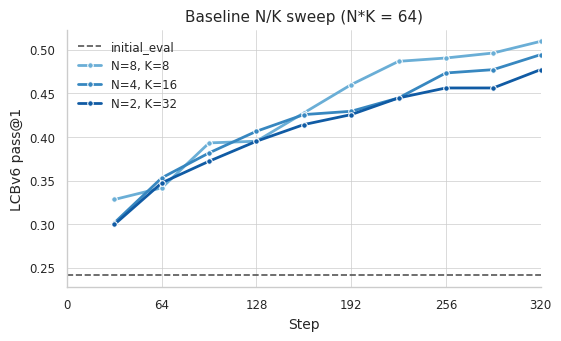

In [13]:
def build_curve_df(setting_order: list[str], value_key: str) -> pd.DataFrame:
    rows = []
    for setting in setting_order:
        d = run_data[setting]
        for _, row in d["eval_df"].iterrows():
            rows.append({"setting": setting, "Step": int(row["eval_step"]), "value": float(row[value_key])})
    df = pd.DataFrame(rows)
    df["setting"] = pd.Categorical(df["setting"], categories=setting_order, ordered=True)
    return df.sort_values(["setting", "Step"]).reset_index(drop=True)


def plot_curve(df: pd.DataFrame, setting_order: list[str], palette: dict, out_name: str,
               *, baseline_value: float, ylabel: str, title: str | None = None, ax=None):
    created = ax is None
    if created:
        fig, ax = plt.subplots(figsize=(5.5, 3.3), constrained_layout=True)
    ax.axhline(baseline_value, color="#555555", linestyle="--", linewidth=1.2, label=INITIAL_RUN_NAME, zorder=1)
    sns.lineplot(data=df, x="Step", y="value", hue="setting", hue_order=setting_order, palette=palette, marker="o",
                 markersize=4, errorbar=None, ax=ax)
    ax.set_xlabel("Step")
    ax.set_ylabel(ylabel)
    ax.set_xlim(0, MAX_STEP)
    ax.set_xticks(range(0, MAX_STEP + 1, 64))
    if title:
        ax.set_title(title)
    ax.legend(frameon=False, loc="best")
    sns.despine(ax=ax)
    if created:
        fig.savefig(OUTPUT_DIR / out_name, bbox_inches="tight")
        return fig, ax
    return None, ax


plot_curve(build_curve_df(BASELINE_SETTING_ORDER, EVAL_KEY), BASELINE_SETTING_ORDER, baseline_palette,
           f"{FIGURE_PREFIX}_baseline_pass_at_1.pdf", baseline_value=INITIAL_PASS_AT_1,
           ylabel="LCBv6 pass@1", title="Baseline N/K sweep (N*K = 64)")
plt.show()

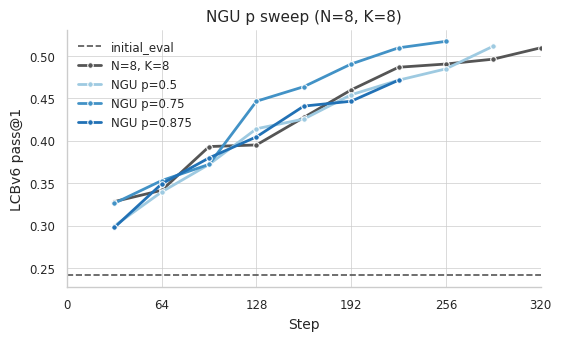

In [14]:
plot_curve(build_curve_df(NGU_SETTING_ORDER, EVAL_KEY), NGU_SETTING_ORDER, ngu_palette,
           f"{FIGURE_PREFIX}_ngu_pass_at_1.pdf", baseline_value=INITIAL_PASS_AT_1,
           ylabel="LCBv6 pass@1", title="NGU p sweep (N=8, K=8)")
plt.show()

### Broken out by reward-fn subset

`code_stdio_lcbv6` (82 prompts) vs. `code_functional_lcbv6` (49). The pooled `eval/pass_at_1`
above is the 131-prompt average of the two, not their unweighted mean.

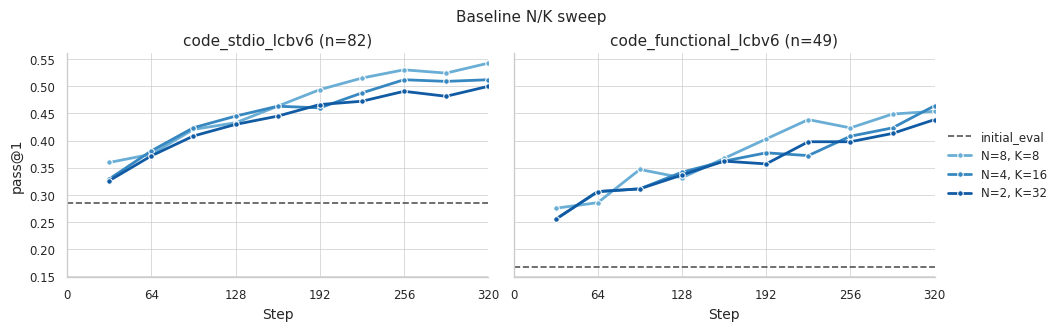

In [15]:
def plot_subset_curves(setting_order: list[str], palette: dict, out_name: str, title: str):
    fig, axes = plt.subplots(1, len(SUBSETS), figsize=(10.5, 3.2), constrained_layout=True, sharey=True)
    for ax, (label, key) in zip(axes, SUBSET_EVAL_KEYS.items()):
        plot_curve(build_curve_df(setting_order, key), setting_order, palette, out_name,
                   baseline_value=INITIAL_SUBSET_PASS_AT_1[label], ylabel="pass@1" if ax is axes[0] else "",
                   title=f"{SUBSETS[label]} (n={SUBSET_SIZES[SUBSETS[label]]})", ax=ax)
        if ax is not axes[-1] and ax.get_legend() is not None:
            ax.get_legend().remove()
    axes[-1].legend(frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0)
    fig.suptitle(title, fontsize=11)
    fig.savefig(OUTPUT_DIR / out_name, bbox_inches="tight")
    return fig, axes


plot_subset_curves(BASELINE_SETTING_ORDER, baseline_palette, f"{FIGURE_PREFIX}_baseline_pass_at_1_by_subset.pdf",
                   "Baseline N/K sweep")
plt.show()

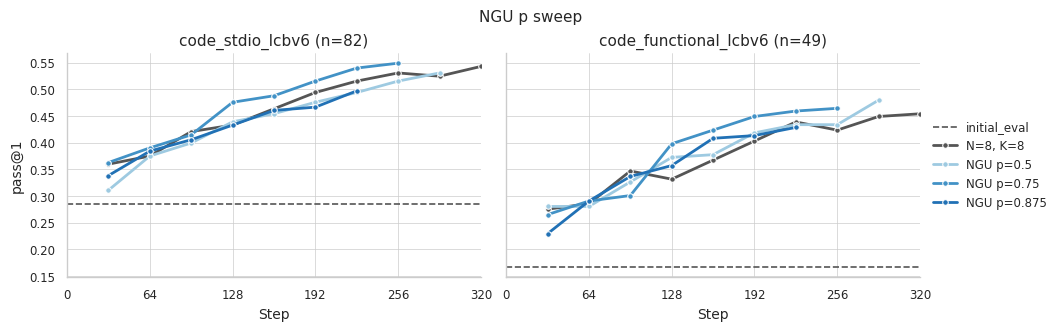

In [16]:
plot_subset_curves(NGU_SETTING_ORDER, ngu_palette, f"{FIGURE_PREFIX}_ngu_pass_at_1_by_subset.pdf", "NGU p sweep")
plt.show()

## pass@k at each run's own best step

The training runs eval with `eval_pass_at_k=4`, so the comparison stops at k=4 (unbiased
estimators). `initial_eval` itself has 32 samples per prompt -- its full ladder out to pass@32
is printed in the difficulty section above, but only the shared k values are plotted here.

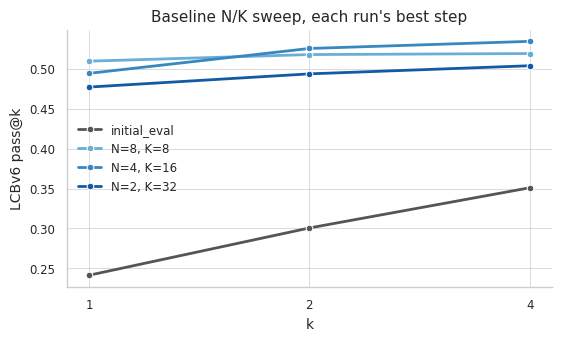

In [17]:
def build_pass_at_k_df(setting_order: list[str]) -> pd.DataFrame:
    rows = [{"setting": INITIAL_RUN_NAME, "k": k, "value": v} for k, v in INITIAL_PASS_AT_K.items()]
    for setting in setting_order:
        best_row = run_data[setting]["best_row"]
        for k, col in PASS_AT_K_HISTORY_COLS.items():
            rows.append({"setting": setting, "k": k, "value": float(best_row[col])})
    df = pd.DataFrame(rows)
    df["setting"] = pd.Categorical(df["setting"], categories=[INITIAL_RUN_NAME, *setting_order], ordered=True)
    return df.sort_values(["setting", "k"]).reset_index(drop=True)


def plot_pass_at_k(setting_order: list[str], palette: dict, out_name: str, title: str | None = None):
    label_order = [INITIAL_RUN_NAME, *setting_order]
    fig, ax = plt.subplots(figsize=(5.5, 3.3), constrained_layout=True)
    sns.lineplot(data=build_pass_at_k_df(setting_order), x="k", y="value", hue="setting", hue_order=label_order,
                 palette={INITIAL_RUN_NAME: "#555555", **palette}, marker="o", errorbar=None, ax=ax)
    ax.set_xlabel("k")
    ax.set_ylabel("LCBv6 pass@k")
    ax.set_xscale("log", base=2)
    ax.set_xticks(K_VALUES)
    ax.set_xticklabels([str(k) for k in K_VALUES])
    if title:
        ax.set_title(title)
    ax.legend(frameon=False, loc="best")
    sns.despine(ax=ax)
    fig.savefig(OUTPUT_DIR / out_name, bbox_inches="tight")
    return fig, ax


plot_pass_at_k(BASELINE_SETTING_ORDER, baseline_palette, f"{FIGURE_PREFIX}_baseline_best_step_pass_at_k.pdf",
               "Baseline N/K sweep, each run's best step")
plt.show()

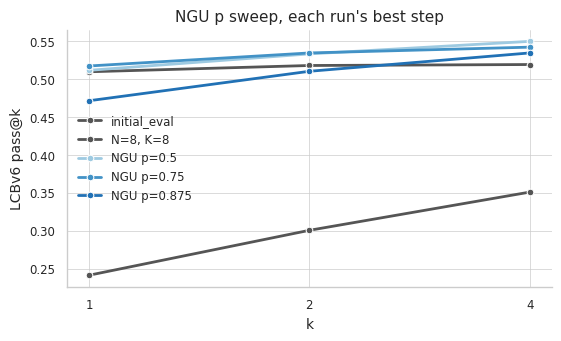

In [18]:
plot_pass_at_k(NGU_SETTING_ORDER, ngu_palette, f"{FIGURE_PREFIX}_ngu_best_step_pass_at_k.pdf",
               "NGU p sweep, each run's best step")
plt.show()

## pass@1 by difficulty bucket, at each run's best step

Both schemes, side by side: model-measured buckets first (comparable with the DeepCoder /
DeepScaler notebooks), then LiveCodeBench's own labels.

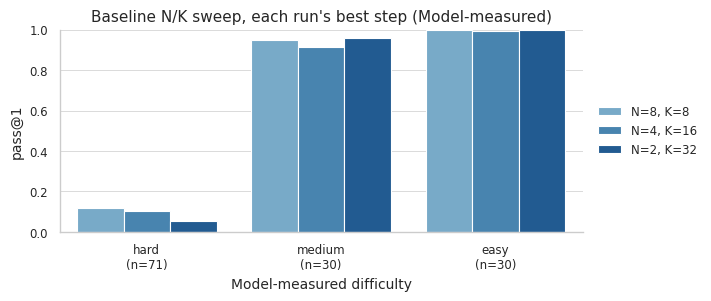

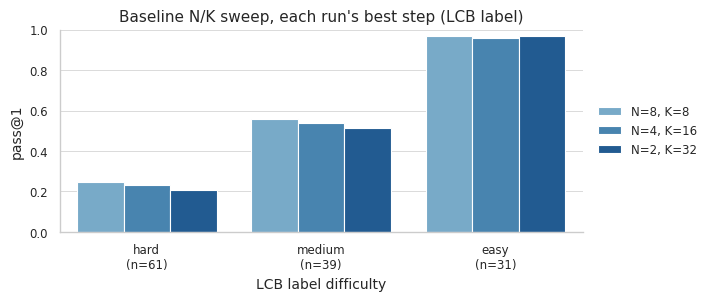

In [19]:
def build_bucket_df(setting_order: list[str], scheme: dict) -> pd.DataFrame:
    rows = []
    for setting in setting_order:
        table_df = run_data[setting]["best_solve_df"].copy()
        table_df["difficulty"] = table_df["dataset_index"].map(scheme["lookup"])
        per_bucket = table_df.groupby("difficulty", observed=True)["solve_rate"].mean()
        for difficulty in DIFFICULTY_ORDER:
            rows.append({"setting": setting, "difficulty": difficulty, "pass_at_1": float(per_bucket[difficulty]),
                         "improvement": (per_bucket[difficulty] - scheme["initial"][difficulty]) * 100})
    df = pd.DataFrame(rows)
    df["setting"] = pd.Categorical(df["setting"], categories=setting_order, ordered=True)
    df["difficulty"] = pd.Categorical(df["difficulty"], categories=DIFFICULTY_ORDER, ordered=True)
    return df


def plot_buckets(setting_order: list[str], palette: dict, ycol: str, ylabel: str, scheme: dict,
                 out_stem: str, title: str | None = None):
    fig, ax = plt.subplots(figsize=(7.0, 2.9), constrained_layout=True)
    sns.barplot(data=build_bucket_df(setting_order, scheme), x="difficulty", y=ycol, hue="setting",
                hue_order=setting_order, palette=palette, order=DIFFICULTY_ORDER, errorbar=None, ax=ax)
    if ycol == "improvement":
        ax.axhline(0, color="black", linewidth=0.8)
    else:
        ax.set_ylim(0, 1)
    ax.set_xlabel(scheme["name"] + " difficulty")
    ax.set_xticks(range(len(DIFFICULTY_ORDER)))
    ax.set_xticklabels(difficulty_tick_labels(scheme))
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(f"{title} ({scheme['name']})")
    ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0)
    sns.despine(ax=ax)
    fig.savefig(OUTPUT_DIR / f"{out_stem}_by_{scheme['slug']}.pdf", bbox_inches="tight")
    return fig, ax


for scheme in SCHEMES:
    plot_buckets(BASELINE_SETTING_ORDER, baseline_palette, "pass_at_1", "pass@1", scheme,
                 f"{FIGURE_PREFIX}_baseline_pass_at_1", "Baseline N/K sweep, each run's best step")
    plt.show()

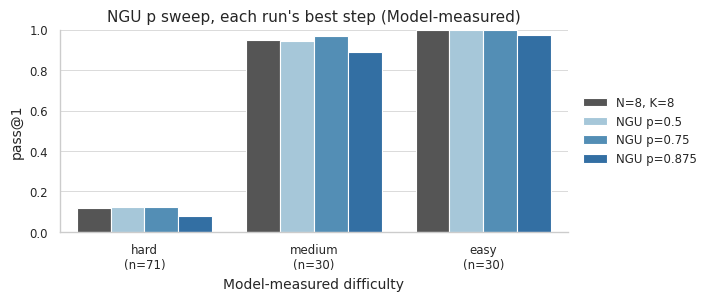

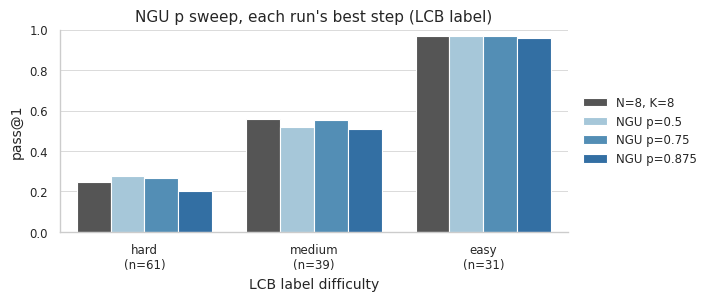

In [20]:
for scheme in SCHEMES:
    plot_buckets(NGU_SETTING_ORDER, ngu_palette, "pass_at_1", "pass@1", scheme,
                 f"{FIGURE_PREFIX}_ngu_pass_at_1", "NGU p sweep, each run's best step")
    plt.show()

### Improvement over `initial_eval`, by difficulty bucket

pass@1 minus `initial_eval`'s pass@1 within the same bucket, in percentage points. Under the
model-measured scheme the `hard` bucket's initial pass@1 is 0 by construction, so its bar is
just the run's raw pass@1 there; under the LCB-label scheme every bucket has a nonzero
starting point, which is exactly why the two sets of bars have different shapes.

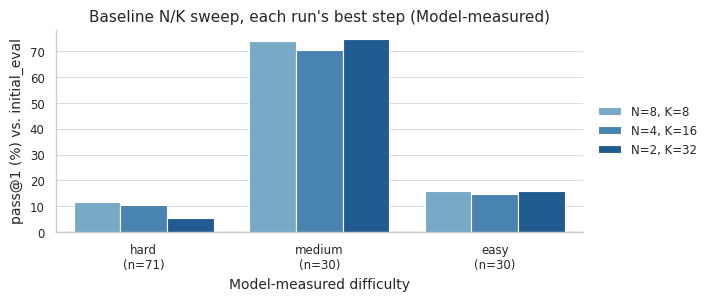

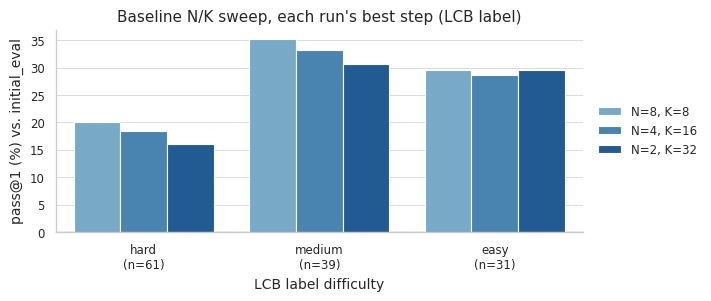

In [21]:
for scheme in SCHEMES:
    plot_buckets(BASELINE_SETTING_ORDER, baseline_palette, "improvement", "pass@1 (%) vs. initial_eval", scheme,
                 f"{FIGURE_PREFIX}_baseline_improvement", "Baseline N/K sweep, each run's best step")
    plt.show()

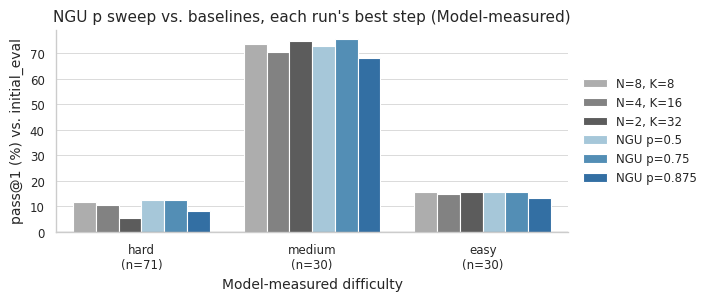

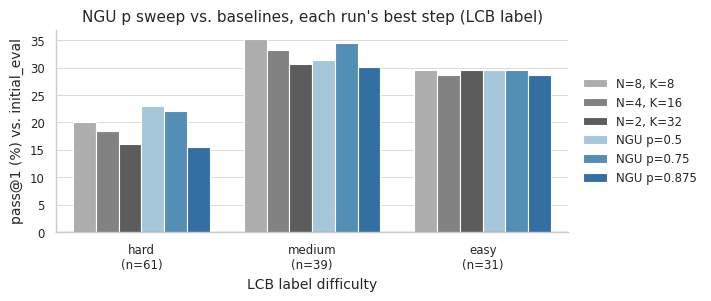

In [22]:
for scheme in SCHEMES:
    plot_buckets(ALL_SETTING_ORDER, all_palette, "improvement", "pass@1 (%) vs. initial_eval", scheme,
                 f"{FIGURE_PREFIX}_ngu_improvement", "NGU p sweep vs. baselines, each run's best step")
    plt.show()

## Training dynamics

`batch/filtered_prompts_pct` is the fraction of sampled prompts thrown away for having zero
advantage std (all-solved or all-unsolved) -- the waste NGU is meant to reduce.
`batch/total_generated_completions` is what that costs in generation per step (the baselines
sit at their fixed `N*K = 64`; NGU generates extra to fill the batch). EMA-smoothed, plotted
against raw training step.

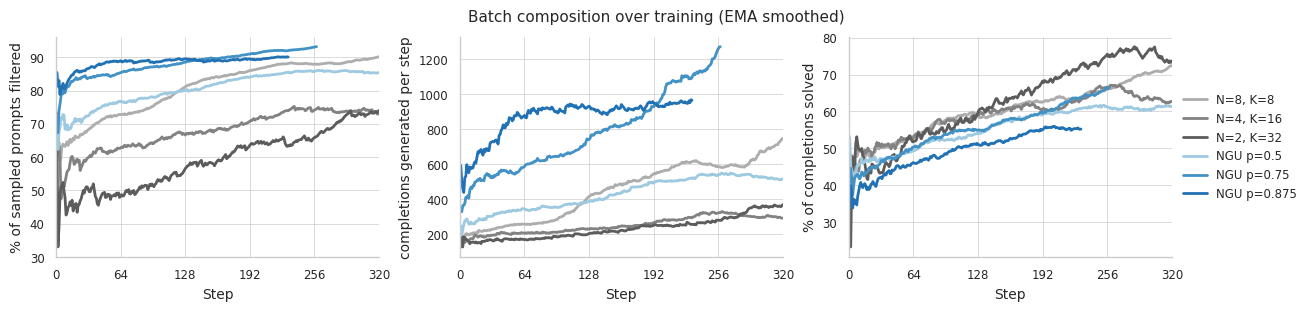

In [23]:
EMA_DECAY = 0.98
BATCH_PANELS = [
    ("batch/filtered_prompts_pct", "% of sampled prompts filtered", 100.0),
    ("batch/total_generated_completions", "completions generated per step", 1.0),
    ("batch/percent_solved_mean", "% of completions solved", 100.0),
]


def build_batch_df(setting_order: list[str]) -> pd.DataFrame:
    frames = []
    for setting in setting_order:
        sub = run_data[setting]["batch_df"]
        frame = pd.DataFrame({"setting": setting, "Step": sub["_step"].astype(int)})
        for col, _, scale in BATCH_PANELS:
            frame[col] = pd.to_numeric(sub[col], errors="coerce") * scale
        frames.append(frame)
    df = pd.concat(frames, ignore_index=True)
    for col, _, _ in BATCH_PANELS:
        df[col] = df.groupby("setting", observed=True)[col].transform(lambda s: s.ewm(alpha=1 - EMA_DECAY, adjust=True).mean())
    df["setting"] = pd.Categorical(df["setting"], categories=setting_order, ordered=True)
    return df


def plot_batch_panels(setting_order: list[str], palette: dict, out_name: str, title: str):
    df = build_batch_df(setting_order)
    fig, axes = plt.subplots(1, len(BATCH_PANELS), figsize=(13.0, 3.0), constrained_layout=True)
    for ax, (col, ylabel, _) in zip(axes, BATCH_PANELS):
        sns.lineplot(data=df, x="Step", y=col, hue="setting", hue_order=setting_order, palette=palette,
                     errorbar=None, ax=ax)
        ax.set_xlabel("Step")
        ax.set_ylabel(ylabel)
        ax.set_xlim(0, MAX_STEP)
        ax.set_xticks(range(0, MAX_STEP + 1, 64))
        if ax.get_legend() is not None:
            ax.get_legend().remove()
        sns.despine(ax=ax)
    axes[-1].legend(frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0)
    fig.suptitle(title, fontsize=11)
    fig.savefig(OUTPUT_DIR / out_name, bbox_inches="tight")
    return fig, axes


plot_batch_panels(ALL_SETTING_ORDER, all_palette, f"{FIGURE_PREFIX}_batch_dynamics.pdf",
                  "Batch composition over training (EMA smoothed)")
plt.show()

## Summary table: LCBv6 pass@1 at each run's best step

Raw scores (%), not improvement over the initial model: the pooled 131-prompt `eval/pass_at_1`
plus its `code_stdio_lcbv6` / `code_functional_lcbv6` breakdown, all read off the same best
step. `Step` is that best step; a run whose eval history stops short of 320 is marked `*`.

In [24]:
TABLE_SECTIONS = [("GRPO Baseline", BASELINE_SETTING_ORDER), ("NGU", NGU_ONLY_SETTING_ORDER)]


def build_raw_score_table() -> pd.DataFrame:
    rows = [{
        "Group": "Initial", "Setting": INITIAL_RUN_NAME, "Step": "0",
        "Stdio": f"{INITIAL_SUBSET_PASS_AT_1['stdio'] * 100:.1f}",
        "Functional": f"{INITIAL_SUBSET_PASS_AT_1['functional'] * 100:.1f}",
        "Total": f"{INITIAL_PASS_AT_1 * 100:.1f}",
    }]
    for group_name, settings in TABLE_SECTIONS:
        for setting in settings:
            spec_row = best_step_df[best_step_df["setting"] == setting].iloc[0]
            incomplete_marker = "*" if spec_row["last_step"] < MAX_STEP else ""
            rows.append({
                "Group": group_name, "Setting": setting, "Step": f"{spec_row['best_step']}{incomplete_marker}",
                "Stdio": f"{spec_row['best_pass_at_1_stdio'] * 100:.1f}",
                "Functional": f"{spec_row['best_pass_at_1_functional'] * 100:.1f}",
                "Total": f"{spec_row['best_pass_at_1'] * 100:.1f}",
            })
    return pd.DataFrame(rows).set_index(["Group", "Setting"])


raw_score_summary_df = build_raw_score_table()
raw_score_summary_df.to_csv(OUTPUT_DIR / f"{FIGURE_PREFIX}_pass_at_1_summary.csv")
print(f"LCBv6 pass@1 (%) at each run's best step; '*' = eval history stops short of step {MAX_STEP}")
display(raw_score_summary_df)

LCBv6 pass@1 (%) at each run's best step; '*' = eval history stops short of step 320


Step Stdio Functional Total
Group         Setting                                  
Initial       initial_eval     0  28.5       16.8  24.1
GRPO Baseline N=8, K=8       320  54.3       45.4  51.0
              N=4, K=16      320  51.2       46.4  49.4
              N=2, K=32      320  50.0       43.9  47.7
NGU           NGU p=0.5     288*  53.0       48.0  51.1
              NGU p=0.75    256*  54.9       46.4  51.7
              NGU p=0.875   224*  49.7       42.9  47.1

## Summary table: LCBv6 pass@1 improvement over `initial_eval`, by difficulty bucket

Same table as the end of `deepcoder_plots.ipynb`: mean solve_rate within each difficulty
bucket at the run's best step, minus `initial_eval`'s pass@1 in that bucket (percentage
points). Columns read easy -> hard, plus a `Total` over all 131 prompts. Single seed per
setting, so there is no ± std here. One table per difficulty scheme -- the `Total` column is
identical across the two (same prompts, different partition), the bucket columns are not.

`SDPO**` is not a run in this sweep: it is sDPO's externally reported LCBv6 pass@1, available
only per *official* LCB label, so it appears in that scheme's table alone. Its raw per-bucket
scores go through the same `initial_eval` subtraction as the runs, and its `Total` is the
prompt-count-weighted mean over the LCB buckets (31 easy / 39 medium / 61 hard) since there is
no per-prompt table for it to average directly.


In [25]:
IMPROVEMENT_TABLE_COLUMN_ORDER = ["easy", "medium", "hard"]
# Externally reported scores that are not wandb runs: raw per-bucket pass@1, given under one
# difficulty scheme only, keyed by that scheme's slug. Everything else about the row is derived
# the same way as the runs' rows.
EXTERNAL_ROWS = {
    "lcb_difficulty": [
        {"group": "SDPO", "setting": "SDPO**", "pass_at_1": {"easy": 0.917, "medium": 0.466, "hard": 0.189}},
    ],
}


def build_improvement_summary_table(scheme: dict) -> pd.DataFrame:
    bucket_lookup = build_bucket_df(ALL_SETTING_ORDER, scheme).set_index(["setting", "difficulty"])["improvement"]
    rows = []
    for group_name, settings in TABLE_SECTIONS:
        for setting in settings:
            spec_row = best_step_df[best_step_df["setting"] == setting].iloc[0]
            row = {"Group": group_name, "Setting": setting,
                   "Step": f"{spec_row['best_step']}{'*' if spec_row['last_step'] < MAX_STEP else ''}"}
            for difficulty in IMPROVEMENT_TABLE_COLUMN_ORDER:
                row[difficulty.capitalize()] = f"{bucket_lookup[(setting, difficulty)]:.1f}"
            row["Total"] = f"{(spec_row['best_pass_at_1'] - INITIAL_PASS_AT_1) * 100:.1f}"
            rows.append(row)
    for entry in EXTERNAL_ROWS.get(scheme["slug"], []):
        # No wandb history, so no best step; Total is the bucket-size-weighted mean of the raw
        # per-bucket scores, which is what averaging over all EVAL_SET_SIZE prompts would give.
        pooled = sum(entry["pass_at_1"][d] * scheme["counts"][d] for d in DIFFICULTY_ORDER) / EVAL_SET_SIZE
        row = {"Group": entry["group"], "Setting": entry["setting"], "Step": ""}
        for difficulty in IMPROVEMENT_TABLE_COLUMN_ORDER:
            row[difficulty.capitalize()] = f"{(entry['pass_at_1'][difficulty] - scheme['initial'][difficulty]) * 100:.1f}"
        row["Total"] = f"{(pooled - INITIAL_PASS_AT_1) * 100:.1f}"
        rows.append(row)
    return pd.DataFrame(rows).set_index(["Group", "Setting"])


improvement_summary_dfs = {}
for scheme in SCHEMES:
    summary_df = build_improvement_summary_table(scheme)
    improvement_summary_dfs[scheme["name"]] = summary_df
    summary_df.to_csv(OUTPUT_DIR / f"{FIGURE_PREFIX}_improvement_by_{scheme['slug']}_summary.csv")
    print(f"LCBv6 pass@1 (%) improvement over initial_eval by {scheme['name']} difficulty, at each run's best step")
    display(summary_df)


LCBv6 pass@1 (%) improvement over initial_eval by Model-measured difficulty, at each run's best step


Step  Easy Medium  Hard Total
Group         Setting                                   
GRPO Baseline N=8, K=8      320  15.7   73.9  11.6  26.8
              N=4, K=16     320  14.9   70.5  10.6  25.3
              N=2, K=32     320  15.7   74.7   5.3  23.6
NGU           NGU p=0.5    288*  15.7   73.0  12.3  27.0
              NGU p=0.75   256*  15.7   75.5  12.3  27.6
              NGU p=0.875  224*  13.2   68.0   8.1  23.0

LCBv6 pass@1 (%) improvement over initial_eval by LCB label difficulty, at each run's best step


Step  Easy Medium  Hard Total
Group         Setting                                   
GRPO Baseline N=8, K=8      320  29.5   35.2  20.1  26.8
              N=4, K=16     320  28.7   33.3  18.4  25.3
              N=2, K=32     320  29.5   30.7  16.0  23.6
NGU           NGU p=0.5    288*  29.5   31.3  23.0  27.0
              NGU p=0.75   256*  29.5   34.5  22.1  27.6
              NGU p=0.875  224*  28.7   30.0  15.6  23.0
SDPO          SDPO**             24.5   26.0  14.4  20.2

Copyable Markdown source for the tables above (printed as plain text so it can be
selected/copied directly, e.g. for pasting into a GitHub PR or `research.md`):

In [26]:
def df_to_markdown(df: pd.DataFrame) -> str:
    # Plain pandas/str implementation (no `tabulate` dependency) so this works in any kernel.
    header = list(df.columns)
    rows = df.astype(str).values.tolist()
    widths = [max(len(h), *(len(r[i]) for r in rows)) if rows else len(h) for i, h in enumerate(header)]

    def fmt_row(cells: list[str]) -> str:
        return "| " + " | ".join(c.ljust(w) for c, w in zip(cells, widths)) + " |"

    lines = [fmt_row(header), fmt_row(["-" * w for w in widths])]
    lines += [fmt_row(r) for r in rows]
    return "\n".join(lines)


def to_copyable(df: pd.DataFrame) -> pd.DataFrame:
    # Paper-facing version of a summary table: `Step` is wandb bookkeeping, so it is dropped here,
    # but the "eval history stops short of MAX_STEP" marker it carried moves onto the setting name
    # so the best-so-far caveat survives the drop.
    incomplete = set(best_step_df.loc[best_step_df["last_step"] < MAX_STEP, "setting"])
    out = df.reset_index()
    out["Setting"] = [f"{setting}*" if setting in incomplete else setting for setting in out["Setting"]]
    return out.drop(columns="Step")


print("pass@1 (%) at each run's best step\n")
print(df_to_markdown(to_copyable(raw_score_summary_df)))
for name, summary_df in improvement_summary_dfs.items():
    print(f"\n\nimprovement over initial_eval (pp), by {name} difficulty\n")
    print(df_to_markdown(to_copyable(summary_df)))
print(f"\n\n*  best-so-far: the run's eval history stops short of step {MAX_STEP}.")
print("** sDPO's reported LCBv6 pass@1, not a run in this sweep (official LCB labels only).")


pass@1 (%) at each run's best step

| Group         | Setting      | Stdio | Functional | Total |
| ------------- | ------------ | ----- | ---------- | ----- |
| Initial       | initial_eval | 28.5  | 16.8       | 24.1  |
| GRPO Baseline | N=8, K=8     | 54.3  | 45.4       | 51.0  |
| GRPO Baseline | N=4, K=16    | 51.2  | 46.4       | 49.4  |
| GRPO Baseline | N=2, K=32    | 50.0  | 43.9       | 47.7  |
| NGU           | NGU p=0.5*   | 53.0  | 48.0       | 51.1  |
| NGU           | NGU p=0.75*  | 54.9  | 46.4       | 51.7  |
| NGU           | NGU p=0.875* | 49.7  | 42.9       | 47.1  |


improvement over initial_eval (pp), by Model-measured difficulty

| Group         | Setting      | Easy | Medium | Hard | Total |
| ------------- | ------------ | ---- | ------ | ---- | ----- |
| GRPO Baseline | N=8, K=8     | 15.7 | 73.9   | 11.6 | 26.8  |
| GRPO Baseline | N=4, K=16    | 14.9 | 70.5   | 10.6 | 25.3  |
| GRPO Baseline | N=2, K=32    | 15.7 | 74.7   | 5.3  | 23.6  |
| NGU           | 